CUDA available: True
GPU: Tesla T4
Memory: 14.6 GB

STFT parameters:
   Window size: 4096
   Hop size: 1024
   Sample rate: 44100 Hz

Generating 30 sec chirp signal...
   Segments: 1288
   CPU time: 0.046138 sec
   GPU time: 0.003269 sec
   Speedup: 14.11x

Generating 60 sec chirp signal...
   Segments: 2580
   CPU time: 0.116237 sec
   GPU time: 0.005509 sec
   Speedup: 21.10x

Generating 120 sec chirp signal...
   Segments: 5164
   CPU time: 0.278762 sec
   GPU time: 0.011836 sec
   Speedup: 23.55x


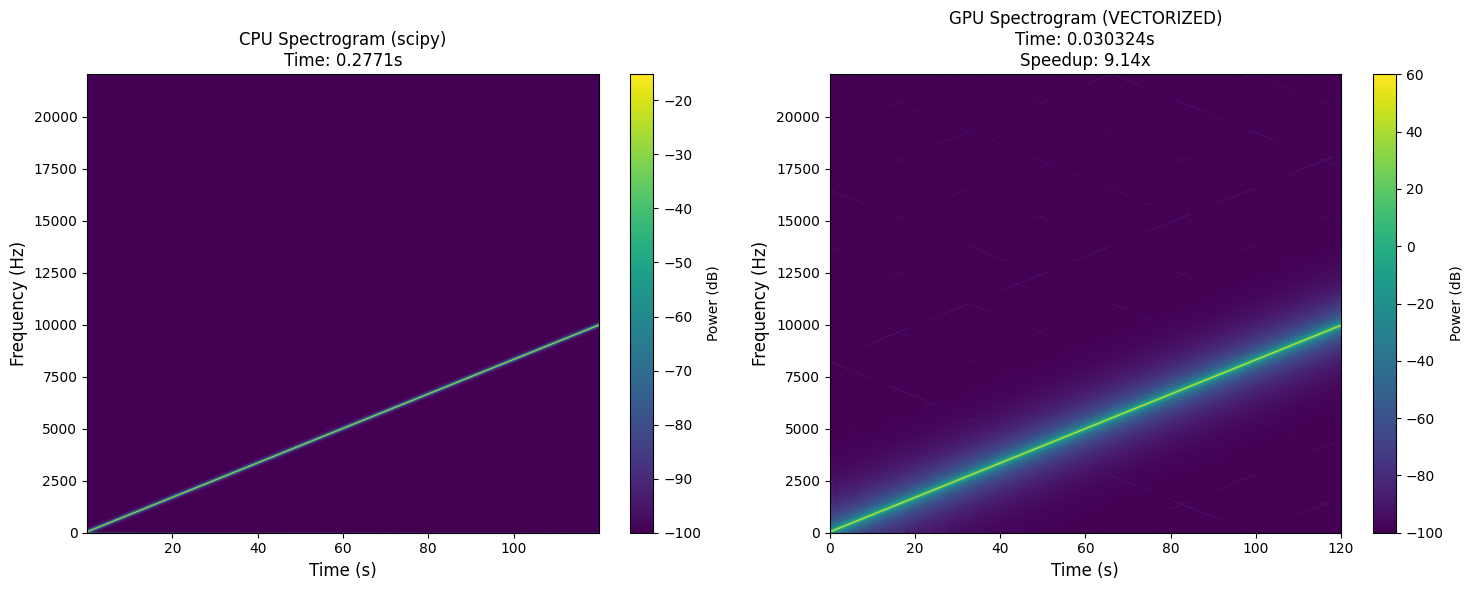

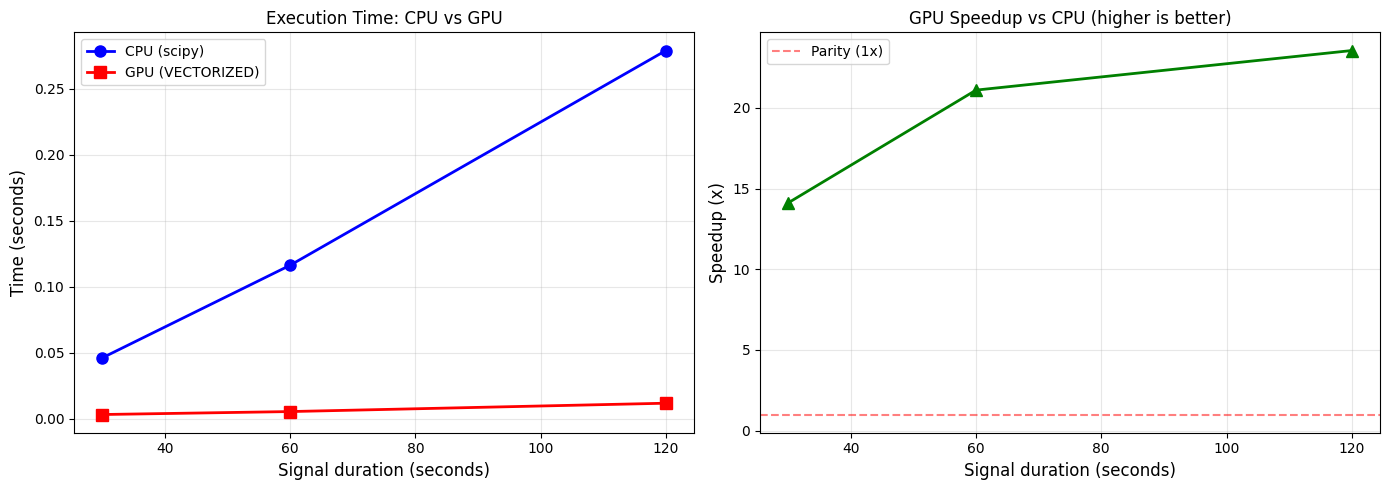


Duration (s)    Segments     CPU time (s)    GPU time (s)    Speedup   
---------------------------------------------------------------------------
30              1288         0.046138        0.003269        14.11     
60              2580         0.116237        0.005509        21.10     
120             5164         0.278762        0.011836        23.55     


In [7]:
import numpy as np
import scipy.signal
import torch
import time
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")



def generate_chirp_signal(duration=3.0, sample_rate=44100, f0=50, f1=10000):
    """Генерирует chirp сигнал"""
    t = np.linspace(0, duration, int(sample_rate * duration))
    signal = scipy.signal.chirp(t, f0, duration, f1, method='linear')
    return signal.astype(np.float32), sample_rate

def compute_spectrogram_cpu(signal_data, sample_rate, window_size=4096, hop_size=1024):
    """Спектрограмма на CPU (scipy)"""
    start = time.perf_counter()
    frequencies, times, spectrogram = scipy.signal.spectrogram(
        signal_data, fs=sample_rate, window='hann',
        nperseg=window_size, noverlap=window_size - hop_size, mode='psd'
    )
    end = time.perf_counter()
    return spectrogram, frequencies, times, end - start

def compute_spectrogram_gpu_vectorized(signal_data, sample_rate, window_size=4096, hop_size=1024):
    """
    Векторизованная версия GPU спектрограммы
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    n_segments = (len(signal_data) - window_size) // hop_size + 1
    n_freqs = window_size // 2 + 1

    # Перенос на GPU
    signal_gpu = torch.from_numpy(signal_data.astype(np.float32)).to(device)

    # Векторизованное создание сегментов
    segments = signal_gpu.unfold(0, window_size, hop_size)

    # Применяем окно Ханна
    window = torch.from_numpy(np.hanning(window_size).astype(np.float32)).to(device)
    segments_windowed = segments * window

    torch.cuda.synchronize()
    start = time.perf_counter()

    fft_result = torch.fft.rfft(segments_windowed, dim=1)
    spectrogram = (fft_result.abs() ** 2).T.cpu().numpy()

    torch.cuda.synchronize()
    end = time.perf_counter()

    frequencies = np.linspace(0, sample_rate / 2, n_freqs)
    times = np.linspace(0, len(signal_data) / sample_rate, n_segments)

    return spectrogram, frequencies, times, end - start

def save_spectrogram_to_bmp(spectrogram_db, filename):
    """Сохранение спектрограммы в BMP файл"""
    spec_norm = (spectrogram_db - spectrogram_db.min()) / (spectrogram_db.max() - spectrogram_db.min())
    spec_norm = (spec_norm * 255).astype(np.uint8)

    height, width = spec_norm.shape
    img_array = np.zeros((height, width, 3), dtype=np.uint8)

    import matplotlib.cm as cm
    cmap = cm.inferno
    colored = (cmap(spec_norm / 255) * 255).astype(np.uint8)
    img_array = colored[:, :, :3]

    img = Image.fromarray(img_array, 'RGB')
    img.save(filename)

durations = [30, 60, 120]
sample_rate = 44100
window_size = 4096
hop_size = 1024

results = []

print(f"\nSTFT parameters:")
print(f"   Window size: {window_size}")
print(f"   Hop size: {hop_size}")
print(f"   Sample rate: {sample_rate} Hz")

for duration in durations:
    print(f"\nGenerating {duration} sec chirp signal...")
    signal_data, fs = generate_chirp_signal(duration=duration, sample_rate=sample_rate)
    n_segments = (len(signal_data) - window_size) // hop_size + 1
    print(f"   Segments: {n_segments}")

    # CPU
    _, _, _, cpu_time = compute_spectrogram_cpu(signal_data, sample_rate, window_size, hop_size)
    print(f"   CPU time: {cpu_time:.6f} sec")

    # GPU
    _, _, _, gpu_time = compute_spectrogram_gpu_vectorized(signal_data, sample_rate, window_size, hop_size)
    print(f"   GPU time: {gpu_time:.6f} sec")

    speedup = cpu_time / gpu_time
    print(f"   Speedup: {speedup:.2f}x")

    results.append({
        'duration': duration,
        'segments': n_segments,
        'cpu_time': cpu_time,
        'gpu_time': gpu_time,
        'speedup': speedup
    })


signal_long, fs = generate_chirp_signal(duration=120, sample_rate=sample_rate)

cpu_spec_long, cpu_freqs, cpu_times, cpu_time_long = compute_spectrogram_cpu(signal_long, sample_rate, window_size, hop_size)
cpu_spec_db = 10 * np.log10(cpu_spec_long + 1e-10)

gpu_spec_long, gpu_freqs, gpu_times, gpu_time_long = compute_spectrogram_gpu_vectorized(signal_long, sample_rate, window_size, hop_size)
gpu_spec_db = 10 * np.log10(gpu_spec_long + 1e-10)

save_spectrogram_to_bmp(cpu_spec_db, "spectrogram_cpu.bmp")
save_spectrogram_to_bmp(gpu_spec_db, "spectrogram_gpu.bmp")

from scipy.io import wavfile
signal_int16 = (signal_long * 32767).astype(np.int16)
wavfile.write("generated_signal.wav", sample_rate, signal_int16)


speedup_long = cpu_time_long / gpu_time_long

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im1 = axes[0].imshow(cpu_spec_db, aspect='auto', origin='lower',
                     extent=[cpu_times[0], cpu_times[-1], cpu_freqs[0], cpu_freqs[-1]])
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)', fontsize=12)
axes[0].set_title(f'CPU Spectrogram (scipy)\nTime: {cpu_time_long:.4f}s')
plt.colorbar(im1, ax=axes[0], label='Power (dB)')

im2 = axes[1].imshow(gpu_spec_db, aspect='auto', origin='lower',
                     extent=[gpu_times[0], gpu_times[-1], gpu_freqs[0], gpu_freqs[-1]])
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)', fontsize=12)
axes[1].set_title(f'GPU Spectrogram (VECTORIZED)\nTime: {gpu_time_long:.6f}s\nSpeedup: {speedup_long:.2f}x')
plt.colorbar(im2, ax=axes[1], label='Power (dB)')

plt.tight_layout()
plt.savefig('spectrogram_results.png', dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

durations_list = [r['duration'] for r in results]
cpu_times_list = [r['cpu_time'] for r in results]
gpu_times_list = [r['gpu_time'] for r in results]
speedups_list = [r['speedup'] for r in results]

ax1 = axes[0]
ax1.plot(durations_list, cpu_times_list, 'o-', label='CPU (scipy)', linewidth=2, markersize=8, color='blue')
ax1.plot(durations_list, gpu_times_list, 's-', label='GPU (VECTORIZED)', linewidth=2, markersize=8, color='red')
ax1.set_xlabel('Signal duration (seconds)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time: CPU vs GPU')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(durations_list, speedups_list, '^-', linewidth=2, markersize=8, color='green')
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Parity (1x)')
ax2.set_xlabel('Signal duration (seconds)', fontsize=12)
ax2.set_ylabel('Speedup (x)', fontsize=12)
ax2.set_title('GPU Speedup vs CPU (higher is better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150)
plt.show()


print(f"\n{'Duration (s)':<15} {'Segments':<12} {'CPU time (s)':<15} {'GPU time (s)':<15} {'Speedup':<10}")
print("-" * 75)

for r in results:
    print(f"{r['duration']:<15} {r['segments']:<12} {r['cpu_time']:<15.6f} {r['gpu_time']:<15.6f} {r['speedup']:<10.2f}")
